In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\vaibh\Desktop\ecommerce_sales_cleaned.csv")

In [3]:
print(df.head())
print(df.info())
print(df.isnull().sum())

  Customer ID  Gender Region  Age Product Name     Category  Unit Price  \
0    CUST0268    Male  North   47      Monitor  Electronics       300.0   
1    CUST0046    Male   West   22   Headphones  Accessories       100.0   
2    CUST0169  Female  South   54      Monitor  Electronics       300.0   
3    CUST0002    Male  North   23   Headphones  Accessories       100.0   
4    CUST0173  Female  South   47       Laptop  Electronics      1500.0   

   Quantity  Total Price  Shipping Fee Shipping Status  Order Date  \
0         5       1500.0         13.31        Returned  08-12-2023   
1         2        200.0          6.93      In Transit  09-04-2023   
2         1        300.0         11.31        Returned  28-08-2023   
3         5        500.0         12.22       Delivered  18-01-2023   
4         3       4500.0          5.40       Delivered  19-01-2023   

   Order Year Order Month  Order Month No Order Value Segment  
0        2023    December              12          High Value  


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Customer ID          1000 non-null   object        
 1   Gender               1000 non-null   object        
 2   Region               1000 non-null   object        
 3   Age                  1000 non-null   int64         
 4   Product Name         1000 non-null   object        
 5   Category             1000 non-null   object        
 6   Unit Price           1000 non-null   float64       
 7   Quantity             1000 non-null   int64         
 8   Total Price          1000 non-null   float64       
 9   Shipping Fee         1000 non-null   float64       
 10  Shipping Status      1000 non-null   object        
 11  Order Date           1000 non-null   datetime64[ns]
 12  Order Year           1000 non-null   int64         
 13  Order Month          1000 non-null

In [5]:
df = df[df['Shipping Status'] != 'In Transit'].copy()

In [6]:
df['Returned'] = (df['Shipping Status'] == 'Returned').astype(int)

In [7]:
df[['Shipping Status', 'Returned']].head()

,Shipping Status,Returned
0,Returned,1
2,Returned,1
3,Delivered,0
4,Delivered,0
7,Returned,1


In [8]:
df['Returned'].value_counts()

Returned
0    363
1    308
Name: count, dtype: int64

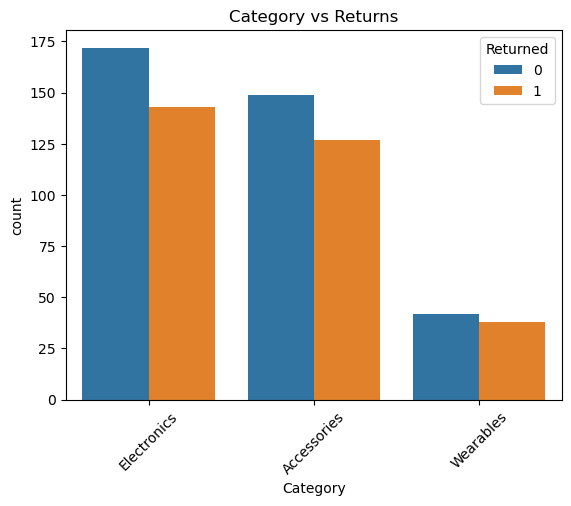

In [9]:
sns.countplot(x='Category', hue='Returned', data=df)
plt.xticks(rotation=45)
plt.title("Category vs Returns")
plt.show()

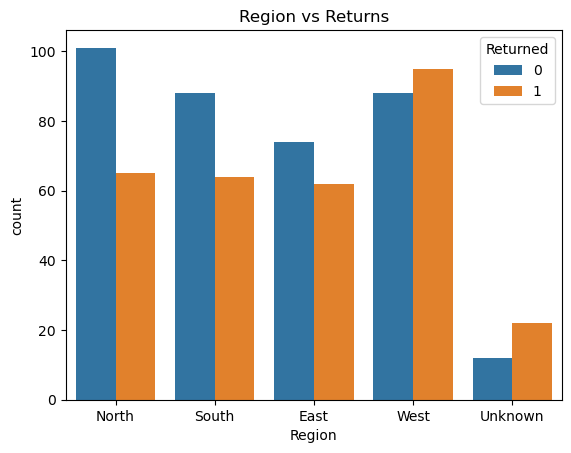

In [10]:
sns.countplot(x='Region', hue='Returned', data=df)
plt.title("Region vs Returns")
plt.show()

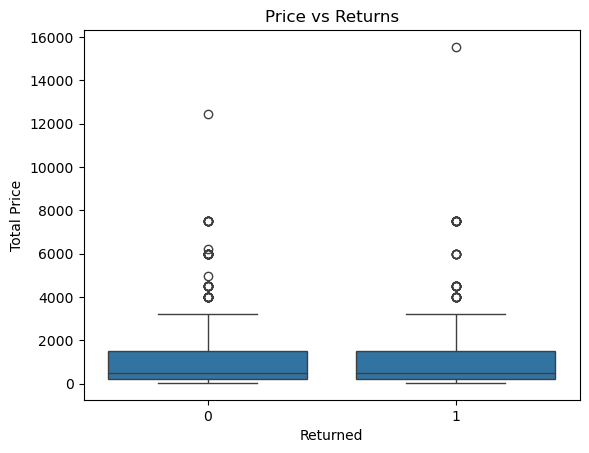

In [11]:
sns.boxplot(x='Returned', y='Total Price', data=df)
plt.title("Price vs Returns")
plt.show()

In [12]:
df_model = df[['Quantity', 'Total Price', 'Category', 'Region', 'Age', 'Shipping Fee', 'Returned']]

In [13]:
df_model = pd.get_dummies(df_model, columns=['Category', 'Region'], drop_first=True)

In [14]:
df_model.head()

,Quantity,Total Price,Age,Shipping Fee,Returned,Category_Electronics,Category_Wearables,Region_North,Region_South,Region_Unknown,Region_West
0,5,1500.0,47,13.31,1,True,False,True,False,False,False
2,1,300.0,54,11.31,1,True,False,False,True,False,False
3,5,500.0,23,12.22,0,False,False,True,False,False,False
4,3,4500.0,47,5.40,0,True,False,False,True,False,False
7,2,100.0,18,15.08,1,False,False,False,True,False,False


In [15]:
X = df_model.drop('Returned', axis=1)
y = df_model['Returned']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [19]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [20]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5925925925925926


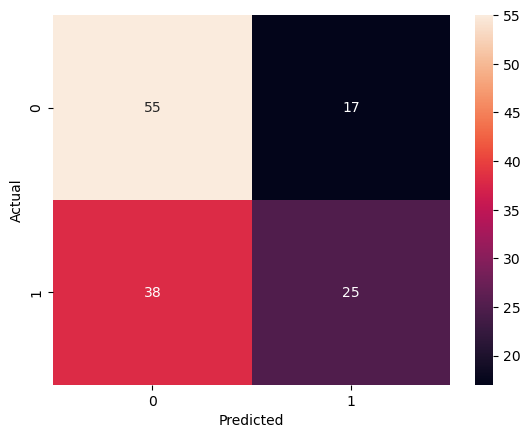

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.76      0.67        72
           1       0.60      0.40      0.48        63

    accuracy                           0.59       135
   macro avg       0.59      0.58      0.57       135
weighted avg       0.59      0.59      0.58       135



In [23]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(by='Coefficient', ascending=False)

print(importance)

                Feature  Coefficient
8        Region_Unknown     0.133989
9           Region_West     0.121037
0              Quantity     0.105119
5    Category_Wearables     0.061898
4  Category_Electronics     0.054602
7          Region_South    -0.002941
2                   Age    -0.056635
1           Total Price    -0.071209
3          Shipping Fee    -0.084089
6          Region_North    -0.146730


In [24]:
df_test = pd.DataFrame(X_test, columns=X.columns)
df_test['Actual'] = y_test.values
df_test['Predicted_Prob'] = y_prob

print(df_test.head())

   Quantity  Total Price       Age  Shipping Fee  Category_Electronics  \
0  1.404727    -0.190347 -0.663481      1.694195             -0.941979   
1 -0.684821    -0.392038  1.400387      1.590079              1.061595   
2  0.011695    -0.240770  0.190533      1.321691              1.061595   
3  1.404727     0.061768  1.400387     -0.964234              1.061595   
4 -0.684821     0.112191  0.759876      0.074612              1.061595   

   Category_Wearables  Region_North  Region_South  Region_Unknown  \
0            2.816617     -0.568733     -0.560112       -0.230315   
1           -0.355036     -0.568733     -0.560112       -0.230315   
2           -0.355036     -0.568733      1.785357       -0.230315   
3           -0.355036     -0.568733      1.785357       -0.230315   
4           -0.355036     -0.568733     -0.560112       -0.230315   

   Region_West  Actual  Predicted_Prob  
0    -0.606092       0        0.496094  
1    -0.606092       0        0.397483  
2    -0.606092   

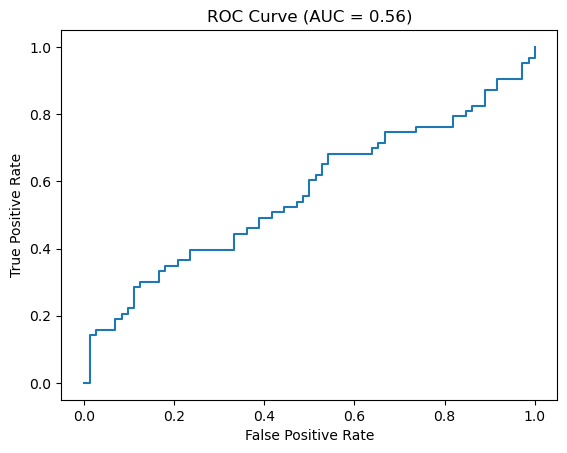

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()